## Figures for Chemical Science manuscript

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import sys
sys.path.append('/biggin/t001/bioc1805/Git/aescore/analysis')
from data import *
from scipy.stats import pearsonr, kendalltau
from sklearn.metrics import mean_squared_error

In [7]:
import matplotlib as mpl
mpl.rcParams['savefig.dpi'] = 600
mpl.rcParams['font.size'] = 10

### Main paper

#### Figure 1: Radial AEV parameters

In [16]:
# To add (Isak)

#### Figure 2: AEV-PLIG model schematic

Created separately.

#### Figure 3: AEV-PLIG baseline performance

In [13]:
def rmse(true, pred):
    return np.sqrt(mean_squared_error(true, pred))

def format_marginal(ax, horizontal=True):

        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        if horizontal:
            ax.spines['left'].set_visible(False)
            ax.invert_xaxis()
            
        else:
            ax.spines['bottom'].set_visible(False)
            ax.invert_yaxis()

        ax.set_ylabel('')
        ax.set_xlabel('')

def plot_scatter_with_marginals(df1, df2, x_col, y_col, group_col, outpath=None):

    fig = plt.figure(figsize=(4, 7), constrained_layout=True)

    widths = [4, 0.6]
    heights = [0.6, 4, 0.6, 4]
    lims = [-16, -2]

    spec = fig.add_gridspec(ncols=2, nrows=4, width_ratios=widths,
                        height_ratios=heights)
    
    # Dotted x=y line
    ax1 = fig.add_subplot(spec[1, 0])
    ax1.plot(lims, lims, linestyle='--', color='gray', alpha=0.7)

    ax2 = fig.add_subplot(spec[3, 0])
    ax2.plot(lims, lims, linestyle='--', color='gray', alpha=0.7)

    # Scatter plots
    sns.scatterplot(data=df1, x=x_col, y=y_col, color='darkorange', ax=ax1, legend=False, edgecolor='black', alpha=0.6, zorder=10)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.set_xlabel('')
    ax1.set_ylabel(r'Pred. $\Delta$G (kcal/mol)')
    ax1.set_xticks([-16,-12,-8,-4])

    sns.scatterplot(data=df2, x=x_col, y=y_col, color='forestgreen', ax=ax2, legend=False,  edgecolor='black', alpha=0.6, zorder=10)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.set_xlabel(r'Exp. $\Delta$G (kcal/mol)')
    ax2.set_ylabel(r'Pred. $\Delta$G (kcal/mol)')
    ax2.set_xticks(np.arange(lims[0],lims[1],-2))
    ax2.set_xticks([-16,-12,-8,-4])

    # Marginal histograms (remove labels, ticks and boxes)
    ax1_marg_x = fig.add_subplot(spec[0, 0])
    sns.kdeplot(data=df1, x=x_col, color='darkorange', ax=ax1_marg_x, legend=False)
    format_marginal(ax1_marg_x)
    ax1_marg_x.set_xlim(lims)
    
    ax1_marg_y = fig.add_subplot(spec[1, 1])
    sns.kdeplot(data=df1, y=y_col, color='darkorange', ax=ax1_marg_y, legend=False)
    format_marginal(ax1_marg_y, horizontal=False)
    ax1_marg_y.set_ylim(lims)

    ax2_marg_x = fig.add_subplot(spec[2, 0])
    sns.kdeplot(data=df2, x=x_col, color='forestgreen', ax=ax2_marg_x, legend=False)
    format_marginal(ax2_marg_x)
    ax2_marg_x.set_xlim(lims)

    ax2_marg_y = fig.add_subplot(spec[3, 1])
    sns.kdeplot(data=df2, y=y_col, color='forestgreen', ax=ax2_marg_y, legend=False)
    format_marginal(ax2_marg_y, horizontal=False)
    ax2_marg_y.set_ylim(lims)

    # Annotations
    ax1.set_title('a)', loc='left', position=(-0.2, 1.0), fontsize=12)
    ax2.set_title('b)', loc='left', position=(-0.2, 1.0), fontsize=12)

    ax1_pcc, ax1_kt, ax1_rmse = pearsonr(df1[x_col], df1[y_col])[0], kendalltau(df1[x_col], df1[y_col])[0], rmse(df1[x_col], df1[y_col])
    ax2_pcc, ax2_kt, ax2_rmse = pearsonr(df2[x_col], df2[y_col])[0], kendalltau(df2[x_col], df2[y_col])[0], rmse(df2[x_col], df2[y_col])
    ax1.text(-16, -4, f'PCC = {ax1_pcc:.2f}\n'+r'K$\tau$ = '+f'{ax1_kt:.2f}\nRMSE = {ax1_rmse:.2f}', fontsize=9)
    ax2.text(-16, -4, f'PCC = {ax2_pcc:.2f}\n'+r'K$\tau$ = '+f'{ax2_kt:.2f}\nRMSE = {ax2_rmse:.2f}', fontsize=9)

    if outpath:
        plt.tight_layout(w_pad=1, h_pad=0)
        plt.savefig(outpath, bbox_inches='tight')

In [14]:
ood_baseline_predictions = pd.read_csv("../data/baseline/ood_test_refined+_predictions.csv")
ood_baseline_predictions.rename(columns={'preds': 'preds_pk'}, inplace=True)
ood_baseline_predictions['Exp. ΔG'] = [pk_to_dg(pk) for pk in ood_baseline_predictions['truth']]
ood_baseline_predictions['preds'] = [pk_to_dg(pk) for pk in ood_baseline_predictions['preds_pk']]
ood_baseline_predictions['Target'] = 'OOD'

casf16_baseline_predictions = pd.read_csv("../data/baseline/casf2016_pdbbind_predictions.csv")
casf16_baseline_predictions.rename(columns={'preds': 'preds_pk'}, inplace=True)
casf16_baseline_predictions['Exp. ΔG'] = [pk_to_dg(pk) for pk in casf16_baseline_predictions['truth']]
casf16_baseline_predictions['preds'] = [pk_to_dg(pk) for pk in casf16_baseline_predictions['preds_pk']]
casf16_baseline_predictions['Target'] = 'CASF2016'

/tmp/ipykernel_2384629/387240159.py:87: UserWarning: The figure layout has changed to tight
  plt.tight_layout(w_pad=1, h_pad=0)


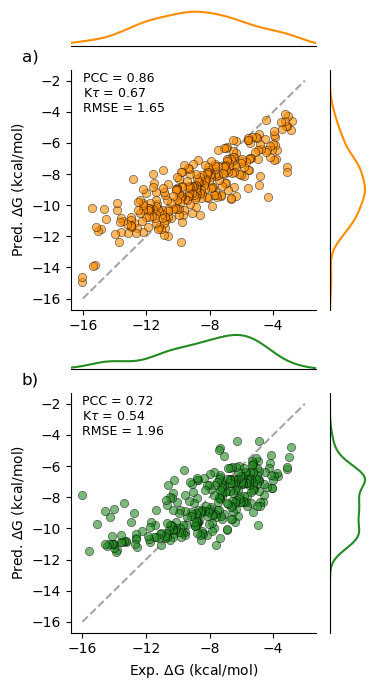

In [17]:
plot_scatter_with_marginals(casf16_baseline_predictions,ood_baseline_predictions, 'Exp. ΔG', 'preds', 'Target', './figure3.pdf')

#### Figure 4: AEV-PLIG performance vs training similarity

In [18]:
# To add (Isak)

#### Figure 5: AEV-PLIG performance vs enrichment/finetuning ligands

In [19]:
# To add (Isak)

#### Figure 6: AEV-PLIG performance vs FEP

In [25]:
def plot_bars_comparison(df1, df2, df3, column1, column2, xlabel='', y1_label='', y2_label='', y1_lim=(0,1), y2_lim=(0,2), outpath=None):
    
    labels = df1.index
    x = [x for x in range(8)] + [x+9 for x in range(8)]
    
    bar_width = 0.23

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9,6), sharex=True, constrained_layout=True)
    
    bars1_1 = ax1.bar(x, df1[column1], bar_width, label='AEV-PLIG', edgecolor='black')
    bars1_2 = ax1.bar([i + bar_width for i in x], df2[column1], bar_width, label='AEV-PLIG (enriched)', edgecolor='black')
    bars1_3 = ax1.bar([i + 2*bar_width for i in x], df3[column1], bar_width, label='FEP', edgecolor='black')

    bars2_1 = ax2.bar(x, df1[column2], bar_width, label='AEV-PLIG', edgecolor='black')
    bars2_2 = ax2.bar([i + bar_width for i in x], df2[column2], bar_width, label='AEV-PLIG (enriched)', edgecolor='black')
    bars2_3 = ax2.bar([i + 2*bar_width for i in x], df3[column2], bar_width, label='FEP', edgecolor='black')

    ax1.set_ylim(y1_lim)
    ax2.set_ylim(y2_lim)

    ax2.set_xlabel(xlabel, labelpad=1)
    ax1.set_ylabel(y1_label)
    ax2.set_ylabel(y2_label)

    ax1.set_xticks([i + bar_width for i in x])
    ax2.set_xticks([i + bar_width for i in x])
    ax2.set_xticklabels(labels)
    ax1.legend(ncol=3, frameon=False, loc='upper left', bbox_to_anchor=(0.24, 1.25))
    
    plt.xticks(rotation=90)

    # Adding horizontal lines and annotations
    ax2.axhline(y=-0.74, xmin=0.05, xmax=0.45, color='black', clip_on=False)
    ax2.axhline(y=-0.74, xmin=0.55, xmax=0.95, color='black', clip_on=False)
    ax2.annotate('Schindler FEP', xy=(0.25, -0.56), 
                xycoords='axes fraction', ha='center', va='center')
    ax2.annotate('Wang FEP', xy=(0.75, -0.56), 
                xycoords='axes fraction', ha='center', va='center')


    if outpath:
        plt.tight_layout(pad=1)
        plt.savefig(outpath, dpi=500)

In [21]:
aevplig_stats_merck = pd.read_csv('../data/bindingnet/merck_pdbbind_U_bindingnet_ligsim90_metrics.csv', index_col=0)
aevplig_stats_merck.sort_index(inplace=True)
aevplig_stats_merck.drop(['mean','weighted_mean'], axis=0, inplace=True)
aevplig_stats_merck.index = ['CDK8', 'c-MET', 'Eg5', 'HIF-2a', 'PFKFB3', 'SHP2', 'SYK', 'TNKS2']

aevplig_enriched_stats_merck = pd.read_csv('../data/bindingnet_enriched/merck_pdbbind_U_bindingnet_ligsim90_finetune3_metrics.csv', index_col=0)
aevplig_enriched_stats_merck.sort_index(inplace=True)
aevplig_enriched_stats_merck.drop(['mean','weighted_mean'], axis=0, inplace=True)
aevplig_enriched_stats_merck.index = ['CDK8', 'c-MET', 'Eg5', 'HIF-2a', 'PFKFB3', 'SHP2', 'SYK', 'TNKS2']

fep_stats_merck = pd.read_csv('../data/fep/schindler_fep_metrics.csv', index_col=0)
fep_stats_merck.sort_index(inplace=True)
fep_stats_merck.drop(['weighted_mean'], axis=0, inplace=True)
fep_stats_merck.index = ['CDK8', 'c-MET', 'Eg5', 'HIF-2a', 'PFKFB3', 'SHP2', 'SYK', 'TNKS2']

In [23]:
aevplig_stats_schro = pd.read_csv('../data/bindingnet/schrodinger_pdbbind_U_bindingnet_ligsim90_metrics.csv', index_col=0)
aevplig_stats_schro.drop(['mean','weighted_mean'], axis=0, inplace=True)
aevplig_stats_schro = aevplig_stats_schro.reindex(['Bace', 'CDK2', 'Jnk1', 'MCL1', 'p38', 'PTP1B', 'Thrombin', 'Tyk2'])
aevplig_stats_schro.index = ['BACE', 'CDK2', 'JNK1', 'MCL1', 'p38', 'PTP1B', 'Thrombin', 'Tyk2']

aevplig_enriched_stats_schro = pd.read_csv('../data/bindingnet_enriched/schrodinger_pdbbind_U_bindingnet_ligsim90_finetune3_metrics.csv', index_col=0)
aevplig_enriched_stats_schro.drop(['mean','weighted_mean'], axis=0, inplace=True)
aevplig_enriched_stats_schro = aevplig_enriched_stats_schro.reindex(['Bace', 'CDK2', 'Jnk1', 'MCL1', 'p38', 'PTP1B', 'Thrombin', 'Tyk2'])
aevplig_enriched_stats_schro.index = ['BACE', 'CDK2', 'JNK1', 'MCL1', 'p38', 'PTP1B', 'Thrombin', 'Tyk2']

fep_stats_schro = pd.read_csv('../data/fep/wang_fep_metrics.csv', index_col=0)
fep_stats_schro.drop(['mean', 'weighted_mean'], axis=0, inplace=True)
fep_stats_schro.sort_index(inplace=True)
fep_stats_schro.index = ['BACE', 'CDK2', 'JNK1', 'MCL1', 'p38', 'PTP1B', 'Thrombin', 'Tyk2']

/tmp/ipykernel_2384629/106460807.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=1)


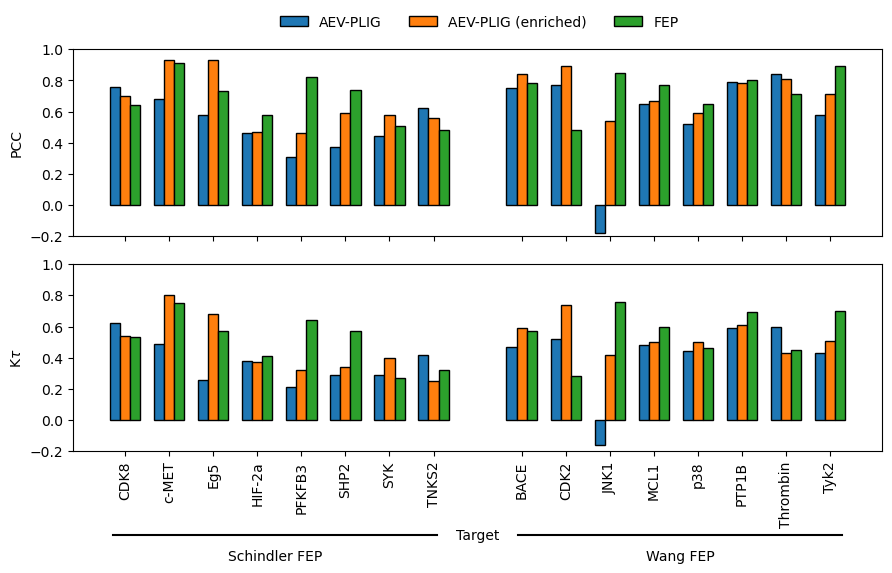

In [28]:
plot_bars_comparison(pd.concat([aevplig_stats_merck, aevplig_stats_schro]), pd.concat([aevplig_enriched_stats_merck, aevplig_enriched_stats_schro]), pd.concat([fep_stats_merck,fep_stats_schro]),"pearson_r", "kendall_tau", xlabel='Target', y1_label='PCC', y2_label=r"K$\tau$", y1_lim=(-0.2,1), y2_lim=(-0.2, 1), outpath='./figure6.pdf')